# 95 — Estimate nodal source positions, then match to Geode metadata

This notebook separates the problem into two parts:

1. Estimate the source position for each nodal event directly from the nodal gather using high-pass filtered energy.
2. Compare those nodal event times/positions against Geode stacked-file metadata using a fixed per-survey clock model.

Important convention used here: **Geode stacked-file times are treated as the final trigger time in a stack**, not the first trigger.


In [1]:
from pathlib import Path
import json
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except Exception as e:
    PLOTLY_AVAILABLE = False
    print("Plotly not available; falling back to matplotlib where possible:", e)

## 1. Configuration

In [2]:
PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"

OUTPUT_DIR = PROJECT_ROOT / "catalog" / "nodal_geode_matching"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_NODAL_TIMEWINDOW_LABEL = "T1_N2_Refraction1m"
TARGET_GEODE_SURVEY = "T1_1m_refraction"

# -------------------------------------------------------------------------
# Per-survey time models
# -------------------------------------------------------------------------
# Sign convention:
#     corrected_utc = recorded_geode_file_time + correction_s
#
# The Geode stacked-file timestamp is treated as the FINAL trigger time
# in a stack. Therefore the stack window is mainly BEFORE this time:
#
#     stack_start = corrected_final_trigger_utc - stack_duration_s
#     stack_end   = corrected_final_trigger_utc + final_margin_s
#
# Daniel / GeoView laptop:
#   likely set to local EDT (UTC-4) and 5 min 33 s fast:
#   actual UTC = recorded file time + 4 hr - 5 min 33 s = +14067 s.
#
# Jochen / EPIC Geode laptop:
#   noted as UTC timezone but 11.5 s ahead of UTC:
#   actual UTC = recorded file time - 11.5 s.
SURVEY_TIME_MODELS = {
    "T1_Streamer_MASW": {
        "correction_s": 4*3600 - 5*60 - 33,  # +14067 s
        "file_time_meaning": "final_trigger",
        "default_stack_duration_s": 120.0,
        "seconds_per_blow": 6.0,
        "min_stack_duration_s": 30.0,
        "max_stack_duration_s": 180.0,
        "final_margin_s": 5.0,
    },
    "T1A_Streamer_MASW": {
        "correction_s": 4*3600 - 5*60 - 33,  # likely same GeoView laptop
        "file_time_meaning": "final_trigger",
        "default_stack_duration_s": 120.0,
        "seconds_per_blow": 6.0,
        "min_stack_duration_s": 30.0,
        "max_stack_duration_s": 180.0,
        "final_margin_s": 5.0,
    },
    "T1_1m_refraction": {
        "correction_s": -11.5,
        "file_time_meaning": "final_trigger",
        "default_stack_duration_s": 120.0,
        "seconds_per_blow": 6.0,
        "min_stack_duration_s": 30.0,
        "max_stack_duration_s": 180.0,
        "final_margin_s": 5.0,
    },
    "T1_2m_refraction": {
        "correction_s": -11.5,  # verify; assumed same EPIC laptop/session unless shown otherwise
        "file_time_meaning": "final_trigger",
        "default_stack_duration_s": 120.0,
        "seconds_per_blow": 6.0,
        "min_stack_duration_s": 30.0,
        "max_stack_duration_s": 180.0,
        "final_margin_s": 5.0,
    },
    # Unknown until checked
    "T3_1m_refraction": {
        "correction_s": 0.0,
        "file_time_meaning": "final_trigger",
        "default_stack_duration_s": 120.0,
        "seconds_per_blow": 6.0,
        "min_stack_duration_s": 30.0,
        "max_stack_duration_s": 180.0,
        "final_margin_s": 5.0,
    },
    "T4_1m_refraction": {
        "correction_s": 0.0,
        "file_time_meaning": "final_trigger",
        "default_stack_duration_s": 120.0,
        "seconds_per_blow": 6.0,
        "min_stack_duration_s": 30.0,
        "max_stack_duration_s": 180.0,
        "final_margin_s": 5.0,
    },
}

# Fallback model if survey name is not found above.
DEFAULT_SURVEY_TIME_MODEL = {
    "correction_s": 0.0,
    "file_time_meaning": "final_trigger",
    "default_stack_duration_s": 120.0,
    "seconds_per_blow": 6.0,
    "min_stack_duration_s": 30.0,
    "max_stack_duration_s": 180.0,
    "final_margin_s": 5.0,
}

SOURCE_POSITION_COMPONENT = "Z"
SOURCE_HP_FREQ_HZ = 25.0
SOURCE_HP_CORNERS = 4
SOURCE_ENERGY_TMIN_S = 0.0
SOURCE_ENERGY_TMAX_S = None
SOURCE_TOP_N = 3
SOURCE_RELATIVE_THRESHOLD = 0.10

MAX_EVENTS_TO_ESTIMATE = None
MAX_MATCHES_TO_DISPLAY = 50

SOURCE_TOLERANCE_M = 3.0

WRITE_SOURCE_ESTIMATES_TO_DB = True
WRITE_MATCH_CANDIDATES_TO_DB = True

print("Catalog:", CATALOG_DB)
print("Output:", OUTPUT_DIR)
print("Target nodal window:", TARGET_NODAL_TIMEWINDOW_LABEL)
print("Target Geode survey:", TARGET_GEODE_SURVEY)


Catalog: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
Output: /Volumes/tachyon/LBSSP_DATA/catalog/nodal_geode_matching
Target nodal window: T1_N2_Refraction1m
Target Geode survey: T1_1m_refraction


## 2. Connect to SQLite catalog and load tables

In [3]:
if not CATALOG_DB.exists():
    raise FileNotFoundError(CATALOG_DB)

conn = sqlite3.connect(CATALOG_DB)

def table_exists(name):
    q = "SELECT name FROM sqlite_master WHERE type='table' AND name=?"
    return conn.execute(q, (name,)).fetchone() is not None

for table in ["shot_events", "shot_gather_files", "trace_index", "picks"]:
    print(table, "exists =", table_exists(table))

shot_events exists = True
shot_gather_files exists = True
trace_index exists = True
picks exists = True


In [4]:
shot_events = pd.read_sql("SELECT * FROM shot_events", conn)
shot_gather_files = pd.read_sql("SELECT * FROM shot_gather_files", conn)
trace_index = pd.read_sql("SELECT * FROM trace_index", conn)
picks = pd.read_sql("SELECT * FROM picks", conn) if table_exists("picks") else pd.DataFrame()

print("shot_events:", len(shot_events))
print("shot_gather_files:", len(shot_gather_files))
print("trace_index:", len(trace_index))
print("picks:", len(picks))

display(shot_events.head())

shot_events: 3752
shot_gather_files: 3610
trace_index: 344514
picks: 787402


,event_id,instrument_system,line,transect,survey,survey_type,shot_no,file_no,source_x_m,source_type,...,metadata_match_time_error_s,detection_n_seed_ids,detection_n_stations,detection_seed_ids,detection_stations,snr_rms,n_receivers_extracted,n_traces_extracted,status,notes
0,GEODE_T1_1M_REFRACTION_F3001,geode,T1,T1,T1_1m_refraction,refraction,1.0,3001.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
1,GEODE_T1_1M_REFRACTION_F3002,geode,T1,T1,T1_1m_refraction,refraction,2.0,3002.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
2,GEODE_T1_1M_REFRACTION_F3003,geode,T1,T1,T1_1m_refraction,refraction,3.0,3003.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
3,GEODE_T1_1M_REFRACTION_F3004,geode,T1,T1,T1_1m_refraction,refraction,4.0,3004.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None
4,GEODE_T1_1M_REFRACTION_F3005,geode,T1,T1,T1_1m_refraction,refraction,5.0,3005.0,82.5,hammer,...,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None


In [5]:
def parse_datetime_col(df, candidates, out_col):
    df = df.copy()
    for c in candidates:
        if c in df.columns:
            dt = pd.to_datetime(df[c], errors="coerce", utc=True)
            if dt.notna().any():
                df[out_col] = dt
                return df
    df[out_col] = pd.NaT
    return df

shot_events = parse_datetime_col(
    shot_events,
    ["event_time_utc", "shot_time_utc", "detection_time_utc", "time_utc"],
    "event_time_dt",
)

shot_events = parse_datetime_col(
    shot_events,
    ["shot_time_utc", "event_time_utc", "detection_time_utc", "file_time_utc"],
    "shot_time_dt",
)

cols = [c for c in ["event_id", "instrument_system", "survey", "line", "timewindow_label", "event_time_dt", "shot_time_dt", "source_x_m"] if c in shot_events.columns]
display(shot_events[cols].head(10))

,event_id,instrument_system,survey,line,timewindow_label,event_time_dt,shot_time_dt,source_x_m
0,GEODE_T1_1M_REFRACTION_F3001,geode,T1_1m_refraction,T1,None,NaT,NaT,82.5
1,GEODE_T1_1M_REFRACTION_F3002,geode,T1_1m_refraction,T1,None,NaT,NaT,82.5
2,GEODE_T1_1M_REFRACTION_F3003,geode,T1_1m_refraction,T1,None,NaT,NaT,82.5
3,GEODE_T1_1M_REFRACTION_F3004,geode,T1_1m_refraction,T1,None,NaT,NaT,82.5
4,GEODE_T1_1M_REFRACTION_F3005,geode,T1_1m_refraction,T1,None,2026-05-18 20:03:54+00:00,2026-05-18 20:03:54+00:00,82.5
5,GEODE_T1_1M_REFRACTION_F3006,geode,T1_1m_refraction,T1,None,2026-05-18 20:08:42+00:00,2026-05-18 20:08:42+00:00,84.5
6,GEODE_T1_1M_REFRACTION_F3007,geode,T1_1m_refraction,T1,None,2026-05-18 20:13:41+00:00,2026-05-18 20:13:41+00:00,86.5
7,GEODE_T1_1M_REFRACTION_F3008,geode,T1_1m_refraction,T1,None,2026-05-18 20:18:44+00:00,2026-05-18 20:18:44+00:00,88.5
8,GEODE_T1_1M_REFRACTION_F3009,geode,T1_1m_refraction,T1,None,2026-05-18 20:21:03+00:00,2026-05-18 20:21:03+00:00,90.5
9,GEODE_T1_1M_REFRACTION_F3010,geode,T1_1m_refraction,T1,None,2026-05-18 20:26:35+00:00,2026-05-18 20:26:35+00:00,92.5


## 3. Select nodal and Geode subsets

In [6]:
nodal_events = shot_events[
    shot_events.get("instrument_system", "").astype(str).str.lower().eq("nodal")
].copy()

if "timewindow_label" not in nodal_events.columns:
    raise ValueError("shot_events has no timewindow_label column")

nodal_subset = nodal_events[
    nodal_events["timewindow_label"].astype(str).eq(TARGET_NODAL_TIMEWINDOW_LABEL)
].copy()

# event_time_dt in shot_events may be empty for nodal rows. That is OK:
# the source-estimation loop below derives event time directly from picks/MiniSEED.
sort_cols = [c for c in ["event_time_dt", "event_id"] if c in nodal_subset.columns]
if sort_cols:
    nodal_subset = nodal_subset.sort_values(sort_cols, na_position="last").reset_index(drop=True)
else:
    nodal_subset = nodal_subset.reset_index(drop=True)

if MAX_EVENTS_TO_ESTIMATE is not None:
    nodal_subset = nodal_subset.head(MAX_EVENTS_TO_ESTIMATE)

print("Target nodal time window:", TARGET_NODAL_TIMEWINDOW_LABEL)
print("Nodal events selected:", len(nodal_subset))
cols = [c for c in ["event_id", "line", "timewindow_label", "event_time_dt", "shot_time_utc", "source_x_m"] if c in nodal_subset.columns]
display(nodal_subset[cols].head(20))


Target nodal time window: T1_N2_Refraction1m
Nodal events selected: 431


,event_id,line,timewindow_label,event_time_dt,shot_time_utc,source_x_m
0,T1_N2_Refraction1m_T1_N2_E00001,T1,T1_N2_Refraction1m,NaT,None,NaN
1,T1_N2_Refraction1m_T1_N2_E00002,T1,T1_N2_Refraction1m,NaT,None,NaN
2,T1_N2_Refraction1m_T1_N2_E00003,T1,T1_N2_Refraction1m,NaT,None,NaN
3,T1_N2_Refraction1m_T1_N2_E00004,T1,T1_N2_Refraction1m,NaT,None,NaN
4,T1_N2_Refraction1m_T1_N2_E00005,T1,T1_N2_Refraction1m,NaT,None,NaN
5,T1_N2_Refraction1m_T1_N2_E00006,T1,T1_N2_Refraction1m,NaT,None,NaN
6,T1_N2_Refraction1m_T1_N2_E00007,T1,T1_N2_Refraction1m,NaT,None,NaN
7,T1_N2_Refraction1m_T1_N2_E00008,T1,T1_N2_Refraction1m,NaT,None,NaN
8,T1_N2_Refraction1m_T1_N2_E00009,T1,T1_N2_Refraction1m,NaT,None,NaN
9,T1_N2_Refraction1m_T1_N2_E00010,T1,T1_N2_Refraction1m,NaT,None,NaN


In [7]:
geode_events = shot_events[
    ~shot_events.get("instrument_system", "").astype(str).str.lower().eq("nodal")
].copy()

if TARGET_GEODE_SURVEY is not None:
    geode_subset = geode_events[
        geode_events.get("survey", "").astype(str).str.lower().eq(TARGET_GEODE_SURVEY.lower())
    ].copy()
else:
    geode_subset = geode_events.copy()

geode_subset = geode_subset.sort_values("event_time_dt").reset_index(drop=True)

print("Target Geode survey:", TARGET_GEODE_SURVEY)
print("Geode events selected:", len(geode_subset))
cols = [c for c in ["event_id", "survey", "line", "event_time_dt", "shot_time_dt", "source_x_m", "file_no", "n_blows"] if c in geode_subset.columns]
display(geode_subset[cols].head(30))

print("Geode rows with usable event_time_dt:", geode_subset["event_time_dt"].notna().sum())
print("Geode rows with usable source_x_m:", pd.to_numeric(geode_subset.get("source_x_m", np.nan), errors="coerce").notna().sum())

Target Geode survey: T1_1m_refraction
Geode events selected: 46


,event_id,survey,line,event_time_dt,shot_time_dt,source_x_m,file_no,n_blows
0,GEODE_T1_1M_REFRACTION_F3005,T1_1m_refraction,T1,2026-05-18 20:03:54+00:00,2026-05-18 20:03:54+00:00,82.5,3005.0,9.0
1,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,2026-05-18 20:08:42+00:00,2026-05-18 20:08:42+00:00,84.5,3006.0,9.0
2,GEODE_T1_1M_REFRACTION_F3007,T1_1m_refraction,T1,2026-05-18 20:13:41+00:00,2026-05-18 20:13:41+00:00,86.5,3007.0,9.0
3,GEODE_T1_1M_REFRACTION_F3008,T1_1m_refraction,T1,2026-05-18 20:18:44+00:00,2026-05-18 20:18:44+00:00,88.5,3008.0,9.0
4,GEODE_T1_1M_REFRACTION_F3009,T1_1m_refraction,T1,2026-05-18 20:21:03+00:00,2026-05-18 20:21:03+00:00,90.5,3009.0,9.0
5,GEODE_T1_1M_REFRACTION_F3010,T1_1m_refraction,T1,2026-05-18 20:26:35+00:00,2026-05-18 20:26:35+00:00,92.5,3010.0,10.0
6,GEODE_T1_1M_REFRACTION_F3011,T1_1m_refraction,T1,2026-05-18 20:36:45+00:00,2026-05-18 20:36:45+00:00,94.5,3011.0,9.0
7,GEODE_T1_1M_REFRACTION_F3012,T1_1m_refraction,T1,2026-05-18 20:41:32+00:00,2026-05-18 20:41:32+00:00,96.5,3012.0,9.0
8,GEODE_T1_1M_REFRACTION_F3013,T1_1m_refraction,T1,2026-05-18 20:47:14+00:00,2026-05-18 20:47:14+00:00,98.5,3013.0,9.0
9,GEODE_T1_1M_REFRACTION_F3014,T1_1m_refraction,T1,2026-05-18 20:51:28+00:00,2026-05-18 20:51:28+00:00,100.5,3014.0,9.0


Geode rows with usable event_time_dt: 42
Geode rows with usable source_x_m: 46


## 4. Helper functions: load nodal gather and estimate source x

In [8]:
def load_nodal_mseed_for_event(event_id):
    q = """
    SELECT file_path
    FROM shot_gather_files
    WHERE event_id = ?
      AND instrument_system = 'nodal'
      AND file_type = 'mseed'
    ORDER BY file_path
    """
    df = pd.read_sql(q, conn, params=[str(event_id)])

    if df.empty:
        raise ValueError(f"No nodal MiniSEED file found for {event_id}")

    path = Path(df.iloc[0]["file_path"])

    if not path.exists():
        raise FileNotFoundError(path)

    return read(str(path)), path


def trace_receiver_x(event_id, tr):
    if not trace_index.empty:
        mask = (
            trace_index["event_id"].astype(str).eq(str(event_id))
            & trace_index["station"].astype(str).eq(str(tr.stats.station))
        )

        if "channel" in trace_index.columns:
            mask = mask & trace_index["channel"].astype(str).eq(str(tr.stats.channel))

        rows = trace_index[mask]

        if len(rows) and "receiver_x_m" in rows.columns:
            return pd.to_numeric(rows.iloc[0]["receiver_x_m"], errors="coerce")

    try:
        return float(tr.stats.station) / 100.0
    except Exception:
        return np.nan


def stream_start_time_dt(st):
    """Return earliest trace start time as pandas UTC Timestamp."""
    if len(st) == 0:
        return pd.NaT
    return pd.to_datetime(
        min(tr.stats.starttime.datetime for tr in st),
        utc=True,
    )


def earliest_pick_time_for_event(event_id):
    """Return earliest absolute pick time for an event, if available."""
    if picks.empty or "event_id" not in picks.columns:
        return pd.NaT

    pk = picks[picks["event_id"].astype(str).eq(str(event_id))].copy()
    if pk.empty:
        return pd.NaT

    for col in ["pick_time_utc", "pick_time", "arrival_time_utc"]:
        if col in pk.columns:
            t = pd.to_datetime(pk[col], errors="coerce", utc=True)
            if t.notna().any():
                return t.min()

    return pd.NaT


def derive_event_time_from_loaded_gather(event_id, st):
    """
    Derive event time while the MiniSEED gather is already loaded.

    Priority:
      1. earliest absolute pick time, if stored in catalog
      2. MiniSEED stream start time
    """
    t_pick = earliest_pick_time_for_event(event_id)

    if pd.notna(t_pick):
        return t_pick, "earliest_pick"

    t_stream = stream_start_time_dt(st)

    if pd.notna(t_stream):
        return t_stream, "mseed_starttime"

    return pd.NaT, "missing"


In [9]:
def estimate_source_x_from_gather(
    event_id,
    st,
    component=SOURCE_POSITION_COMPONENT,
    hp_freq_hz=SOURCE_HP_FREQ_HZ,
    hp_corners=SOURCE_HP_CORNERS,
    energy_tmin_s=SOURCE_ENERGY_TMIN_S,
    energy_tmax_s=SOURCE_ENERGY_TMAX_S,
    top_n=SOURCE_TOP_N,
    relative_threshold=SOURCE_RELATIVE_THRESHOLD,
):
    """
    Estimate source x from a nodal shot gather using high-pass filtered energy.

    Method:
      1. Select one component, usually Z.
      2. High-pass filter each trace to suppress low-frequency ground roll.
      3. Compute energy over the event window.
      4. Estimate source x from an energy-weighted average of the strongest receivers.
    """

    rows = []
    t0 = min(tr.stats.starttime for tr in st)

    for tr in st:
        ch = tr.stats.channel

        if component and not ch.endswith(component):
            continue

        x_m = trace_receiver_x(event_id, tr)

        if not np.isfinite(x_m) or tr.stats.npts == 0:
            continue

        dt = float(tr.stats.delta)

        tr_work = tr.copy()
        tr_work.detrend("linear")
        tr_work.taper(max_percentage=0.02)

        rel_start_s = tr_work.stats.starttime - t0

        i1 = max(0, int(round((energy_tmin_s - rel_start_s) / dt)))

        if energy_tmax_s is None:
            i2 = tr_work.stats.npts
        else:
            i2 = min(tr_work.stats.npts, int(round((energy_tmax_s - rel_start_s) / dt)))

        if i2 <= i1 + 5:
            continue

        raw = tr_work.data[i1:i2].astype(float)
        raw = raw - np.nanmedian(raw)

        tr_hp = tr_work.copy()
        tr_hp.filter("highpass", freq=hp_freq_hz, corners=hp_corners, zerophase=True)
        hp = tr_hp.data[i1:i2].astype(float)
        hp = hp - np.nanmedian(hp)

        rows.append({
            "station": tr.stats.station,
            "channel": ch,
            "receiver_x_m": float(x_m),
            "energy_raw": float(np.nansum(raw**2)),
            "energy_hp25": float(np.nansum(hp**2)),
            "rms_raw": float(np.sqrt(np.nanmean(raw**2))),
            "rms_hp25": float(np.sqrt(np.nanmean(hp**2))),
            "peak_abs_raw": float(np.nanmax(np.abs(raw))) if len(raw) else np.nan,
            "peak_abs_hp25": float(np.nanmax(np.abs(hp))) if len(hp) else np.nan,
        })

    metric = pd.DataFrame(rows)

    if metric.empty:
        return {
            "estimated_source_x_m": np.nan,
            "estimation_method": "none",
            "energy_x_m": np.nan,
            "metric": metric,
            "top_energy_receivers": [],
        }

    metric["receiver_x_m"] = pd.to_numeric(metric["receiver_x_m"], errors="coerce")
    metric["energy_hp25"] = pd.to_numeric(metric["energy_hp25"], errors="coerce")
    metric = metric.dropna(subset=["receiver_x_m", "energy_hp25"])

    if metric.empty:
        return {
            "estimated_source_x_m": np.nan,
            "estimation_method": "none_after_cleaning",
            "energy_x_m": np.nan,
            "metric": metric,
            "top_energy_receivers": [],
        }

    metric_sorted = metric.sort_values("energy_hp25", ascending=False).copy()
    emax = metric_sorted["energy_hp25"].max()

    top = metric_sorted[metric_sorted["energy_hp25"] >= relative_threshold * emax].copy()

    if len(top) < 2:
        top = metric_sorted.head(top_n).copy()

    xs = top["receiver_x_m"].to_numpy(dtype=float)
    weights = top["energy_hp25"].to_numpy(dtype=float)

    if np.nansum(weights) > 0:
        estimated_x = float(np.nansum(xs * weights) / np.nansum(weights))
    else:
        estimated_x = float(metric_sorted.iloc[0]["receiver_x_m"])

    energy_x = float(metric_sorted.iloc[0]["receiver_x_m"])

    top_records = top[
        ["station", "channel", "receiver_x_m", "energy_hp25", "rms_hp25", "peak_abs_hp25"]
    ].to_dict("records")

    return {
        "estimated_source_x_m": estimated_x,
        "estimation_method": f"weighted_energy_hp{int(hp_freq_hz)}",
        "energy_x_m": energy_x,
        "metric": metric,
        "top_energy_receivers": top_records,
    }

## 5. Estimate source position for nodal events

In [10]:
source_estimate_rows = []

for i, row in nodal_subset.iterrows():
    event_id = row["event_id"]
    print(f"[{i+1}/{len(nodal_subset)}] {event_id}")

    try:
        st, mseed_path = load_nodal_mseed_for_event(event_id)

        # Critical: derive event time here, while the MiniSEED gather is already loaded.
        # This avoids depending on missing shot_time_utc/event_time_utc columns in shot_events.
        event_time_dt, event_time_method = derive_event_time_from_loaded_gather(event_id, st)

        est = estimate_source_x_from_gather(
            event_id,
            st,
            component=SOURCE_POSITION_COMPONENT,
        )

        source_estimate_rows.append({
            "event_id": event_id,
            "line": row.get("line"),
            "timewindow_label": row.get("timewindow_label"),
            "event_time_utc": event_time_dt.isoformat() if pd.notna(event_time_dt) else None,
            "event_time_method": event_time_method,
            "estimated_source_x_m": est["estimated_source_x_m"],
            "estimation_method": est["estimation_method"],
            "energy_x_m": est["energy_x_m"],
            "top_energy_receivers_json": json.dumps(est["top_energy_receivers"]),
            "mseed_path": str(mseed_path),
            "error": None,
        })

    except Exception as e:
        print("  FAILED:", e)
        source_estimate_rows.append({
            "event_id": event_id,
            "line": row.get("line"),
            "timewindow_label": row.get("timewindow_label"),
            "event_time_utc": None,
            "event_time_method": "failed",
            "estimated_source_x_m": np.nan,
            "estimation_method": "failed",
            "energy_x_m": np.nan,
            "top_energy_receivers_json": "[]",
            "mseed_path": None,
            "error": str(e),
        })

source_estimates = pd.DataFrame(source_estimate_rows)
source_estimates["event_time_dt"] = pd.to_datetime(source_estimates["event_time_utc"], errors="coerce", utc=True)

print("Source estimates:", len(source_estimates))
print("Event time methods:")
print(source_estimates["event_time_method"].value_counts(dropna=False))
print("Valid event times:")
print(source_estimates["event_time_dt"].notna().value_counts())
display(source_estimates.head())
display(source_estimates["estimated_source_x_m"].describe())


[1/431] T1_N2_Refraction1m_T1_N2_E00001
[2/431] T1_N2_Refraction1m_T1_N2_E00002
[3/431] T1_N2_Refraction1m_T1_N2_E00003
[4/431] T1_N2_Refraction1m_T1_N2_E00004
[5/431] T1_N2_Refraction1m_T1_N2_E00005
[6/431] T1_N2_Refraction1m_T1_N2_E00006
[7/431] T1_N2_Refraction1m_T1_N2_E00007
[8/431] T1_N2_Refraction1m_T1_N2_E00008
[9/431] T1_N2_Refraction1m_T1_N2_E00009
[10/431] T1_N2_Refraction1m_T1_N2_E00010
[11/431] T1_N2_Refraction1m_T1_N2_E00011
[12/431] T1_N2_Refraction1m_T1_N2_E00012
[13/431] T1_N2_Refraction1m_T1_N2_E00013
[14/431] T1_N2_Refraction1m_T1_N2_E00014
[15/431] T1_N2_Refraction1m_T1_N2_E00015
[16/431] T1_N2_Refraction1m_T1_N2_E00016
[17/431] T1_N2_Refraction1m_T1_N2_E00017
[18/431] T1_N2_Refraction1m_T1_N2_E00018
[19/431] T1_N2_Refraction1m_T1_N2_E00019
[20/431] T1_N2_Refraction1m_T1_N2_E00020
[21/431] T1_N2_Refraction1m_T1_N2_E00021
[22/431] T1_N2_Refraction1m_T1_N2_E00022
[23/431] T1_N2_Refraction1m_T1_N2_E00023
[24/431] T1_N2_Refraction1m_T1_N2_E00024
[25/431] T1_N2_Refraction

,event_id,line,timewindow_label,event_time_utc,event_time_method,estimated_source_x_m,estimation_method,energy_x_m,top_energy_receivers_json,mseed_path,error,event_time_dt
0,T1_N2_Refraction1m_T1_N2_E00001,T1,T1_N2_Refraction1m,2026-05-18T16:07:22.366000+00:00,earliest_pick,83.920167,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,None,2026-05-18 16:07:22.366000+00:00
1,T1_N2_Refraction1m_T1_N2_E00002,T1,T1_N2_Refraction1m,2026-05-18T16:07:35.900000+00:00,earliest_pick,83.954618,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,None,2026-05-18 16:07:35.900000+00:00
2,T1_N2_Refraction1m_T1_N2_E00003,T1,T1_N2_Refraction1m,2026-05-18T16:07:44.010000+00:00,earliest_pick,83.821893,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,None,2026-05-18 16:07:44.010000+00:00
3,T1_N2_Refraction1m_T1_N2_E00004,T1,T1_N2_Refraction1m,2026-05-18T16:07:53.424000+00:00,earliest_pick,83.970530,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,None,2026-05-18 16:07:53.424000+00:00
4,T1_N2_Refraction1m_T1_N2_E00005,T1,T1_N2_Refraction1m,2026-05-18T16:08:00.014000+00:00,earliest_pick,83.864182,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,None,2026-05-18 16:08:00.014000+00:00


count    431.000000
mean     124.929677
std       22.425322
min       83.821893
25%      106.084149
50%      124.197145
75%      141.826622
max      163.440819
Name: estimated_source_x_m, dtype: float64

In [11]:
source_est_csv = OUTPUT_DIR / f"nodal_source_estimates_{TARGET_NODAL_TIMEWINDOW_LABEL}.csv"
source_estimates.to_csv(source_est_csv, index=False)
print("Wrote:", source_est_csv)

if WRITE_SOURCE_ESTIMATES_TO_DB:
    conn.execute("""
        CREATE TABLE IF NOT EXISTS nodal_source_estimates (
            event_id TEXT PRIMARY KEY,
            line TEXT,
            timewindow_label TEXT,
            event_time_utc TEXT,
            event_time_method TEXT,
            estimated_source_x_m REAL,
            estimation_method TEXT,
            energy_x_m REAL,
            top_energy_receivers_json TEXT,
            mseed_path TEXT,
            error TEXT
        )
    """)

    # Add event_time_method if an older version of the table exists.
    existing_cols = {
        row[1] for row in conn.execute("PRAGMA table_info(nodal_source_estimates)").fetchall()
    }
    if "event_time_method" not in existing_cols:
        conn.execute("ALTER TABLE nodal_source_estimates ADD COLUMN event_time_method TEXT")

    conn.execute(
        "DELETE FROM nodal_source_estimates WHERE timewindow_label = ?",
        (TARGET_NODAL_TIMEWINDOW_LABEL,),
    )

    db_cols = [
        "event_id",
        "line",
        "timewindow_label",
        "event_time_utc",
        "event_time_method",
        "estimated_source_x_m",
        "estimation_method",
        "energy_x_m",
        "top_energy_receivers_json",
        "mseed_path",
        "error",
    ]

    source_estimates[db_cols].to_sql(
        "nodal_source_estimates",
        conn,
        if_exists="append",
        index=False,
    )
    conn.commit()
    print("Updated SQLite table: nodal_source_estimates")


Wrote: /Volumes/tachyon/LBSSP_DATA/catalog/nodal_geode_matching/nodal_source_estimates_T1_N2_Refraction1m.csv
Updated SQLite table: nodal_source_estimates


## 6. Visualize nodal source position versus time

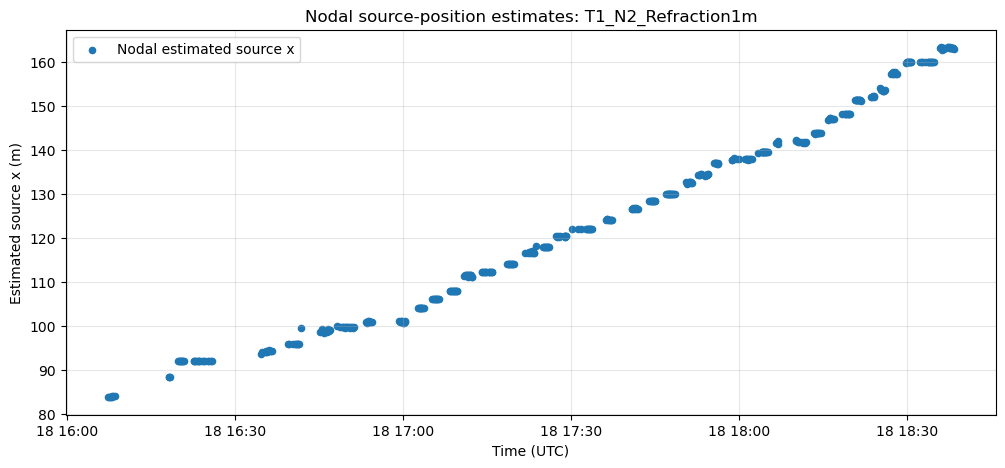

In [12]:
plot_df = source_estimates.dropna(
    subset=["event_time_dt", "estimated_source_x_m"]
).copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(
    plot_df["event_time_dt"],
    plot_df["estimated_source_x_m"],
    s=20,
    label="Nodal estimated source x",
)

ax.set_title(f"Nodal source-position estimates: {TARGET_NODAL_TIMEWINDOW_LABEL}")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Estimated source x (m)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [13]:
plot_df = source_estimates.dropna(
    subset=["event_time_dt", "estimated_source_x_m"]
).copy()

if PLOTLY_AVAILABLE:
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=plot_df["event_time_dt"],
        y=plot_df["estimated_source_x_m"],
        mode="markers",
        name="Nodal source estimates",
        marker=dict(size=6),
        text=plot_df["event_id"],
        hovertemplate=(
            "event=%{text}<br>"
            "time=%{x}<br>"
            "estimated x=%{y:.2f} m<extra></extra>"
        ),
    ))

    fig.update_layout(
        title=f"Zoomable nodal source-position estimates: {TARGET_NODAL_TIMEWINDOW_LABEL}",
        xaxis_title="Time (UTC)",
        yaxis_title="Estimated source x (m)",
        hovermode="closest",
        height=600,
    )

    fig.show()
else:
    print("Plotly not available.")


## 7. Compare nodal source estimates to Geode file times/positions

In [14]:
def survey_time_model(survey):
    survey = str(survey)
    return SURVEY_TIME_MODELS.get(survey, DEFAULT_SURVEY_TIME_MODEL)


def stack_duration_s_for_geode_row(row):
    model = survey_time_model(row.get("survey"))
    default_duration = float(model["default_stack_duration_s"])

    n_blows = row.get("n_blows", np.nan)
    try:
        n_blows = float(n_blows)
    except Exception:
        n_blows = np.nan

    if np.isfinite(n_blows) and n_blows > 1:
        duration = (n_blows - 1.0) * float(model["seconds_per_blow"])
        duration = max(float(model["min_stack_duration_s"]), duration)
        duration = min(float(model["max_stack_duration_s"]), duration)
        return float(duration)

    return default_duration


def add_geode_time_model_columns(geode_df):
    out = geode_df.copy()
    out["source_x_m"] = pd.to_numeric(out.get("source_x_m"), errors="coerce")

    corrections = []
    stack_durations = []
    final_margins = []
    meanings = []

    for _, row in out.iterrows():
        model = survey_time_model(row.get("survey"))
        corrections.append(float(model["correction_s"]))
        stack_durations.append(stack_duration_s_for_geode_row(row))
        final_margins.append(float(model["final_margin_s"]))
        meanings.append(model["file_time_meaning"])

    out["geode_time_correction_s"] = corrections
    out["file_time_meaning"] = meanings
    out["stack_duration_s"] = stack_durations
    out["final_margin_s"] = final_margins

    # recorded event_time_dt is treated as the recorded FINAL trigger time.
    out["corrected_final_trigger_dt"] = (
        out["event_time_dt"] + pd.to_timedelta(out["geode_time_correction_s"], unit="s")
    )

    out["stack_start_dt"] = (
        out["corrected_final_trigger_dt"] - pd.to_timedelta(out["stack_duration_s"], unit="s")
    )
    out["stack_end_dt"] = (
        out["corrected_final_trigger_dt"] + pd.to_timedelta(out["final_margin_s"], unit="s")
    )

    return out


geode_plot = add_geode_time_model_columns(geode_subset)

cols = [
    c for c in [
        "event_id",
        "survey",
        "file_no",
        "event_time_dt",
        "geode_time_correction_s",
        "corrected_final_trigger_dt",
        "stack_start_dt",
        "stack_end_dt",
        "source_x_m",
        "n_blows",
        "stack_duration_s",
    ]
    if c in geode_plot.columns
]
display(geode_plot[cols].head(30))

print("Time model for target survey:")
print(survey_time_model(TARGET_GEODE_SURVEY))


,event_id,survey,file_no,event_time_dt,geode_time_correction_s,corrected_final_trigger_dt,stack_start_dt,stack_end_dt,source_x_m,n_blows,stack_duration_s
0,GEODE_T1_1M_REFRACTION_F3005,T1_1m_refraction,3005.0,2026-05-18 20:03:54+00:00,-11.5,2026-05-18 20:03:42.500000+00:00,2026-05-18 20:02:54.500000+00:00,2026-05-18 20:03:47.500000+00:00,82.5,9.0,48.0
1,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,3006.0,2026-05-18 20:08:42+00:00,-11.5,2026-05-18 20:08:30.500000+00:00,2026-05-18 20:07:42.500000+00:00,2026-05-18 20:08:35.500000+00:00,84.5,9.0,48.0
2,GEODE_T1_1M_REFRACTION_F3007,T1_1m_refraction,3007.0,2026-05-18 20:13:41+00:00,-11.5,2026-05-18 20:13:29.500000+00:00,2026-05-18 20:12:41.500000+00:00,2026-05-18 20:13:34.500000+00:00,86.5,9.0,48.0
3,GEODE_T1_1M_REFRACTION_F3008,T1_1m_refraction,3008.0,2026-05-18 20:18:44+00:00,-11.5,2026-05-18 20:18:32.500000+00:00,2026-05-18 20:17:44.500000+00:00,2026-05-18 20:18:37.500000+00:00,88.5,9.0,48.0
4,GEODE_T1_1M_REFRACTION_F3009,T1_1m_refraction,3009.0,2026-05-18 20:21:03+00:00,-11.5,2026-05-18 20:20:51.500000+00:00,2026-05-18 20:20:03.500000+00:00,2026-05-18 20:20:56.500000+00:00,90.5,9.0,48.0
5,GEODE_T1_1M_REFRACTION_F3010,T1_1m_refraction,3010.0,2026-05-18 20:26:35+00:00,-11.5,2026-05-18 20:26:23.500000+00:00,2026-05-18 20:25:29.500000+00:00,2026-05-18 20:26:28.500000+00:00,92.5,10.0,54.0
6,GEODE_T1_1M_REFRACTION_F3011,T1_1m_refraction,3011.0,2026-05-18 20:36:45+00:00,-11.5,2026-05-18 20:36:33.500000+00:00,2026-05-18 20:35:45.500000+00:00,2026-05-18 20:36:38.500000+00:00,94.5,9.0,48.0
7,GEODE_T1_1M_REFRACTION_F3012,T1_1m_refraction,3012.0,2026-05-18 20:41:32+00:00,-11.5,2026-05-18 20:41:20.500000+00:00,2026-05-18 20:40:32.500000+00:00,2026-05-18 20:41:25.500000+00:00,96.5,9.0,48.0
8,GEODE_T1_1M_REFRACTION_F3013,T1_1m_refraction,3013.0,2026-05-18 20:47:14+00:00,-11.5,2026-05-18 20:47:02.500000+00:00,2026-05-18 20:46:14.500000+00:00,2026-05-18 20:47:07.500000+00:00,98.5,9.0,48.0
9,GEODE_T1_1M_REFRACTION_F3014,T1_1m_refraction,3014.0,2026-05-18 20:51:28+00:00,-11.5,2026-05-18 20:51:16.500000+00:00,2026-05-18 20:50:28.500000+00:00,2026-05-18 20:51:21.500000+00:00,100.5,9.0,48.0


Time model for target survey:
{'correction_s': -11.5, 'file_time_meaning': 'final_trigger', 'default_stack_duration_s': 120.0, 'seconds_per_blow': 6.0, 'min_stack_duration_s': 30.0, 'max_stack_duration_s': 180.0, 'final_margin_s': 5.0}


In [15]:
plot_df = source_estimates.dropna(
    subset=["event_time_dt", "estimated_source_x_m"]
).copy()

geode_plot_clean = geode_plot.dropna(
    subset=["event_time_dt", "source_x_m"]
).copy()

if PLOTLY_AVAILABLE:
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=plot_df["event_time_dt"],
        y=plot_df["estimated_source_x_m"],
        mode="markers",
        name="Nodal detections",
        marker=dict(size=6, color="blue"),
        text=plot_df["event_id"],
        hovertemplate=(
            "nodal event=%{text}<br>"
            "time=%{x}<br>"
            "estimated x=%{y:.2f} m<extra></extra>"
        ),
    ))

    # Stack windows as horizontal line segments.
    for _, gr in geode_plot_clean.iterrows():
        if pd.notna(gr.get("stack_start_dt")) and pd.notna(gr.get("stack_end_dt")):
            fig.add_trace(go.Scatter(
                x=[gr["stack_start_dt"], gr["stack_end_dt"]],
                y=[gr["source_x_m"], gr["source_x_m"]],
                mode="lines",
                line=dict(color="rgba(255,0,0,0.25)", width=4),
                showlegend=False,
                hoverinfo="skip",
            ))

    fig.add_trace(go.Scatter(
        x=geode_plot_clean["event_time_dt"],
        y=geode_plot_clean["source_x_m"],
        mode="markers",
        name="Geode recorded final trigger",
        marker=dict(size=9, color="red", symbol="x"),
        text=geode_plot_clean["event_id"],
        hovertemplate=(
            "geode event=%{text}<br>"
            "recorded final trigger=%{x}<br>"
            "source x=%{y:.2f} m<extra></extra>"
        ),
    ))

    fig.add_trace(go.Scatter(
        x=geode_plot_clean["corrected_final_trigger_dt"],
        y=geode_plot_clean["source_x_m"],
        mode="markers",
        name="Geode corrected final trigger",
        marker=dict(size=9, color="orange", symbol="diamond"),
        text=geode_plot_clean["event_id"],
        hovertemplate=(
            "geode event=%{text}<br>"
            "corrected final trigger=%{x}<br>"
            "source x=%{y:.2f} m<extra></extra>"
        ),
    ))

    fig.update_layout(
        title=f"Nodal detections vs Geode final-trigger stack windows: {TARGET_NODAL_TIMEWINDOW_LABEL} / {TARGET_GEODE_SURVEY}",
        xaxis_title="Time",
        yaxis_title="Source position x (m)",
        hovermode="closest",
        height=750,
    )

    fig.show()
else:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(plot_df["event_time_dt"], plot_df["estimated_source_x_m"], s=20, label="Nodal")
    ax.scatter(geode_plot_clean["event_time_dt"], geode_plot_clean["source_x_m"], s=40, marker="x", label="Geode recorded final")
    ax.scatter(geode_plot_clean["corrected_final_trigger_dt"], geode_plot_clean["source_x_m"], s=40, marker="D", label="Geode corrected final")
    for _, gr in geode_plot_clean.iterrows():
        ax.plot([gr["stack_start_dt"], gr["stack_end_dt"]], [gr["source_x_m"], gr["source_x_m"]], alpha=0.25)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


## 8. Estimate fixed Geode clock offset from first nodal event near each shot position

In [16]:
def nodal_events_near_source(
    geode_row,
    source_estimates,
    max_dx_m=3.0,
    max_dt_s=600.0,
    use_recorded_time=True,
):
    gx = pd.to_numeric(pd.Series([geode_row.get("source_x_m", np.nan)]), errors="coerce").iloc[0]
    gt = geode_row.get("event_time_dt", pd.NaT) if use_recorded_time else geode_row.get("corrected_final_trigger_dt", pd.NaT)

    if not np.isfinite(gx) or pd.isna(gt):
        return pd.DataFrame()

    df = source_estimates.copy()
    df["estimated_source_x_m"] = pd.to_numeric(df["estimated_source_x_m"], errors="coerce")
    df = df.dropna(subset=["estimated_source_x_m", "event_time_dt"])

    df["source_x_residual_m"] = df["estimated_source_x_m"] - gx
    df["time_residual_recorded_s"] = (df["event_time_dt"] - gt).dt.total_seconds()

    df = df[
        (df["source_x_residual_m"].abs() <= max_dx_m)
        & (df["time_residual_recorded_s"].abs() <= max_dt_s)
    ].copy()

    return df.sort_values(["event_time_dt", "source_x_residual_m"])


clock_rows = []

for _, gr in geode_plot.iterrows():
    near = nodal_events_near_source(
        gr,
        source_estimates,
        max_dx_m=SOURCE_TOLERANCE_M,
        max_dt_s=600.0,
        use_recorded_time=True,
    )

    if near.empty:
        continue

    first = near.sort_values("event_time_dt").iloc[0]
    last = near.sort_values("event_time_dt").iloc[-1]

    # Because Geode stacked-file time is treated as the FINAL trigger time,
    # the last nodal event near this source position should best estimate the
    # corrected Geode final trigger time.
    clock_rows.append({
        "geode_event_id": gr.get("event_id"),
        "geode_file_no": gr.get("file_no"),
        "geode_source_x_m": gr.get("source_x_m"),
        "geode_recorded_final_time_utc": gr.get("event_time_dt").isoformat() if pd.notna(gr.get("event_time_dt")) else None,

        "first_nodal_event_id": first["event_id"],
        "first_nodal_time_utc": first["event_time_dt"].isoformat(),
        "first_nodal_estimated_x_m": first["estimated_source_x_m"],

        "last_nodal_event_id": last["event_id"],
        "last_nodal_time_utc": last["event_time_dt"].isoformat(),
        "last_nodal_estimated_x_m": last["estimated_source_x_m"],

        "source_x_residual_first_m": first["source_x_residual_m"],
        "source_x_residual_last_m": last["source_x_residual_m"],

        "first_nodal_minus_geode_recorded_s": first["time_residual_recorded_s"],
        "last_nodal_minus_geode_recorded_s": last["time_residual_recorded_s"],

        # This is the fixed correction one would infer from this file if
        # the last nodal event corresponds to the final Geode trigger.
        "implied_geode_correction_s": last["time_residual_recorded_s"],

        "n_nodal_events_near_source": len(near),
        "nodal_stack_span_s": (last["event_time_dt"] - first["event_time_dt"]).total_seconds(),
    })

clock_offsets = pd.DataFrame(clock_rows)

print("Clock-offset estimates:", len(clock_offsets))
display(clock_offsets.head(30))

if len(clock_offsets):
    display(clock_offsets["implied_geode_correction_s"].describe())


Clock-offset estimates: 0


""


In [17]:
if len(clock_offsets):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        clock_offsets["geode_source_x_m"],
        clock_offsets["implied_geode_offset_s"],
        "o-",
    )
    ax.axhline(GEODE_FIXED_OFFSET_S, color="red", linestyle="--", label=f"current offset {GEODE_FIXED_OFFSET_S:+.1f} s")
    ax.set_xlabel("Geode source x (m)")
    ax.set_ylabel("Implied offset: nodal time - Geode recorded time (s)")
    ax.set_title("Estimated Geode clock offset from first nodal event near each shot position")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    clock_csv = OUTPUT_DIR / f"clock_offset_estimates_{TARGET_GEODE_SURVEY}.csv"
    clock_offsets.to_csv(clock_csv, index=False)
    print("Wrote:", clock_csv)

## 9. Deterministic matching using fixed offset and stack window

In [18]:
def match_nodal_to_geode_fixed_time_model(
    source_estimates,
    geode_plot,
    source_tolerance_m=SOURCE_TOLERANCE_M,
):
    rows = []

    nodal = source_estimates.copy()
    nodal["estimated_source_x_m"] = pd.to_numeric(nodal["estimated_source_x_m"], errors="coerce")
    nodal = nodal.dropna(subset=["estimated_source_x_m", "event_time_dt"])

    for _, gr in geode_plot.iterrows():
        gx = pd.to_numeric(pd.Series([gr.get("source_x_m", np.nan)]), errors="coerce").iloc[0]

        stack_start = gr.get("stack_start_dt", pd.NaT)
        stack_end = gr.get("stack_end_dt", pd.NaT)
        corrected_final = gr.get("corrected_final_trigger_dt", pd.NaT)

        if pd.isna(stack_start) or pd.isna(stack_end) or not np.isfinite(gx):
            continue

        cand = nodal[
            (nodal["event_time_dt"] >= stack_start)
            & (nodal["event_time_dt"] <= stack_end)
        ].copy()

        if cand.empty:
            continue

        cand["source_x_residual_m"] = cand["estimated_source_x_m"] - gx
        cand = cand[cand["source_x_residual_m"].abs() <= source_tolerance_m].copy()

        if cand.empty:
            continue

        cand["time_residual_to_final_s"] = (cand["event_time_dt"] - corrected_final).dt.total_seconds()
        cand["time_since_stack_start_s"] = (cand["event_time_dt"] - stack_start).dt.total_seconds()

        for _, nr in cand.sort_values("event_time_dt").iterrows():
            rows.append({
                "nodal_event_id": nr["event_id"],
                "nodal_time_utc": nr["event_time_dt"].isoformat(),
                "nodal_estimated_source_x_m": nr["estimated_source_x_m"],
                "nodal_timewindow_label": nr["timewindow_label"],

                "geode_event_id": gr.get("event_id"),
                "geode_survey": gr.get("survey"),
                "geode_file_no": gr.get("file_no"),
                "geode_recorded_final_time_utc": gr.get("event_time_dt").isoformat() if pd.notna(gr.get("event_time_dt")) else None,
                "geode_corrected_final_time_utc": corrected_final.isoformat() if pd.notna(corrected_final) else None,
                "geode_stack_start_utc": stack_start.isoformat() if pd.notna(stack_start) else None,
                "geode_stack_end_utc": stack_end.isoformat() if pd.notna(stack_end) else None,
                "geode_time_correction_s": gr.get("geode_time_correction_s"),
                "geode_source_x_m": gx,

                "source_type": gr.get("source_type"),
                "operator": gr.get("operator"),
                "plate_type": gr.get("plate_type"),
                "n_blows": gr.get("n_blows"),
                "stack_duration_s": gr.get("stack_duration_s"),

                "time_residual_to_final_s": nr["time_residual_to_final_s"],
                "time_since_stack_start_s": nr["time_since_stack_start_s"],
                "source_x_residual_m": nr["source_x_residual_m"],
                "match_status": "candidate_fixed_time_model_final_trigger",
            })

    return pd.DataFrame(rows)


matches = match_nodal_to_geode_fixed_time_model(
    source_estimates,
    geode_plot,
    source_tolerance_m=SOURCE_TOLERANCE_M,
)

print("Deterministic matches:", len(matches))
display(matches.head(MAX_MATCHES_TO_DISPLAY))


Deterministic matches: 0


""


In [19]:
match_csv = OUTPUT_DIR / f"nodal_geode_matches_{TARGET_NODAL_TIMEWINDOW_LABEL}_{TARGET_GEODE_SURVEY}.csv"
matches.to_csv(match_csv, index=False)
print("Wrote:", match_csv)

if WRITE_MATCH_CANDIDATES_TO_DB:
    conn.execute("""
        CREATE TABLE IF NOT EXISTS nodal_geode_match_candidates (
            nodal_event_id TEXT,
            nodal_time_utc TEXT,
            nodal_estimated_source_x_m REAL,
            nodal_timewindow_label TEXT,
            geode_event_id TEXT,
            geode_survey TEXT,
            geode_file_no TEXT,
            geode_recorded_final_time_utc TEXT,
            geode_corrected_final_time_utc TEXT,
            geode_stack_start_utc TEXT,
            geode_stack_end_utc TEXT,
            geode_time_correction_s REAL,
            geode_source_x_m REAL,
            source_type TEXT,
            operator TEXT,
            plate_type TEXT,
            n_blows REAL,
            stack_duration_s REAL,
            time_residual_to_final_s REAL,
            time_since_stack_start_s REAL,
            source_x_residual_m REAL,
            match_status TEXT
        )
    """)

    # If an older version exists, add missing columns.
    existing_cols = {
        row[1] for row in conn.execute("PRAGMA table_info(nodal_geode_match_candidates)").fetchall()
    }
    for col, typ in {
        "geode_recorded_final_time_utc": "TEXT",
        "geode_corrected_final_time_utc": "TEXT",
        "geode_stack_start_utc": "TEXT",
        "geode_stack_end_utc": "TEXT",
        "geode_time_correction_s": "REAL",
        "stack_duration_s": "REAL",
        "time_residual_to_final_s": "REAL",
        "time_since_stack_start_s": "REAL",
    }.items():
        if col not in existing_cols:
            conn.execute(f"ALTER TABLE nodal_geode_match_candidates ADD COLUMN {col} {typ}")

    conn.execute(
        "DELETE FROM nodal_geode_match_candidates WHERE nodal_timewindow_label = ? AND geode_survey = ?",
        (TARGET_NODAL_TIMEWINDOW_LABEL, TARGET_GEODE_SURVEY),
    )

    if len(matches):
        matches.to_sql(
            "nodal_geode_match_candidates",
            conn,
            if_exists="append",
            index=False,
        )

    conn.commit()
    print("Updated SQLite table: nodal_geode_match_candidates")


Wrote: /Volumes/tachyon/LBSSP_DATA/catalog/nodal_geode_matching/nodal_geode_matches_T1_N2_Refraction1m_T1_1m_refraction.csv


OperationalError: no such column: nodal_timewindow_label

## 10. Inspect one match or off-end shot

In [ ]:
INSPECT_EVENT_ID = matches["nodal_event_id"].iloc[0] if len(matches) else source_estimates["event_id"].iloc[0]

print("Inspecting:", INSPECT_EVENT_ID)

st, _ = load_nodal_mseed_for_event(INSPECT_EVENT_ID)
est = estimate_source_x_from_gather(INSPECT_EVENT_ID, st, component=SOURCE_POSITION_COMPONENT)
metric = est["metric"].sort_values("receiver_x_m").copy()

display(metric.sort_values("energy_hp25", ascending=False).head(12))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(metric["receiver_x_m"], metric["energy_hp25"], "o-", label="HP25 energy")
ax.axvline(est["estimated_source_x_m"], color="green", label=f"estimated {est['estimated_source_x_m']:.2f} m")

if len(matches):
    m = matches[matches["nodal_event_id"].astype(str).eq(str(INSPECT_EVENT_ID))]
    if len(m):
        gx = float(m.iloc[0]["geode_source_x_m"])
        ax.axvline(gx, color="red", linestyle="--", label=f"Geode source {gx:.2f} m")

ax.set_xlabel("Receiver x (m)")
ax.set_ylabel("HP25 energy")
ax.set_title(INSPECT_EVENT_ID)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Notes

- Nodal event time is derived in the source-estimation loop, when the MiniSEED gather is loaded.
- Priority is earliest catalog pick time, then MiniSEED stream starttime.
- Geode stacked-file time is treated as the final trigger time in a stack.
- Survey-specific time correction is applied using `SURVEY_TIME_MODELS`.
- Matching uses the corrected final trigger time and a stack window that extends backward from that time.
- Source position is estimated independently from nodal HP25 energy before any Geode matching.
